### 导入包及数据部分

In [1]:
import numpy as np  #导入numpy，用于科学计算，如，矩阵运算
from sklearn.neighbors import KNeighborsClassifier   # 包装好的knn算法
from collections import defaultdict
import collections
import matplotlib.pyplot as plt
import csv

def get_K_from_csv_no_pandas(filepath):
    with open(filepath, newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            return int(row['K'])     # 只返回第一个，转成整数

def file2matrix(filename):
    fr = open(filename)
    numberOfLines = len(fr.readlines())         #get the number of lines in the file
    returnMat = np.zeros((numberOfLines,9))        #prepare matrix to return  the number of features
    classLabelVector = []                       #prepare labels return
    fr = open(filename)
    index = 0
    for line in fr.readlines():
        line = line.strip()
        listFromLine = line.split('\t')
        returnMat[index,:] = listFromLine[0:9]     #chose features
        classLabelVector.append(float(listFromLine[-1]))
        #classLabelVector.append(float(0))
        index += 1
    return returnMat,classLabelVector

### 生成KNN分类器

In [2]:
data_X,data_y = file2matrix('matlab_source/digits/sample.dat')
data_y_name = ['BPSK','QPSK','16QAM','64QAM']#分类名称
X_train = data_X  #numpy ndarray格式
y_train = data_y  #numpy ndarray格式
n_neighbors = get_K_from_csv_no_pandas('matlab_source/const.csv')
kNN_classifier = KNeighborsClassifier(n_neighbors=n_neighbors)     # knn中k值
kNN_classifier.fit(X_train, y_train)  # fit 拟合

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### BPSKModulationClassTest

the total correct rate on -4 dB SNR is: 0.0
正确判断为BPSK: 0.0
判断为QPSK: 0.0
判断为16QAM: 5.0
判断为64QAM: 995.0
the total correct rate on -2 dB SNR is: 0.0
正确判断为BPSK: 0.0
判断为QPSK: 0.0
判断为16QAM: 86.0
判断为64QAM: 914.0
the total correct rate on 0 dB SNR is: 0.0
正确判断为BPSK: 0.0
判断为QPSK: 1.0
判断为16QAM: 961.0
判断为64QAM: 38.0
the total correct rate on 2 dB SNR is: 0.0
正确判断为BPSK: 0.0
判断为QPSK: 964.0
判断为16QAM: 36.0
判断为64QAM: 0.0
the total correct rate on 4 dB SNR is: 0.0
正确判断为BPSK: 0.0
判断为QPSK: 1000.0
判断为16QAM: 0.0
判断为64QAM: 0.0
the total correct rate on 6 dB SNR is: 0.005
正确判断为BPSK: 5.0
判断为QPSK: 995.0
判断为16QAM: 0.0
判断为64QAM: 0.0
the total correct rate on 8 dB SNR is: 1.0
正确判断为BPSK: 1000.0
判断为QPSK: 0.0
判断为16QAM: 0.0
判断为64QAM: 0.0
the total correct rate on 10 dB SNR is: 1.0
正确判断为BPSK: 1000.0
判断为QPSK: 0.0
判断为16QAM: 0.0
判断为64QAM: 0.0
OrderedDict({-4: 0.0, -2: 0.0, 0: 0.0, 2: 0.0, 4: 0.0, 6: 0.005, 8: 1.0, 10: 1.0})


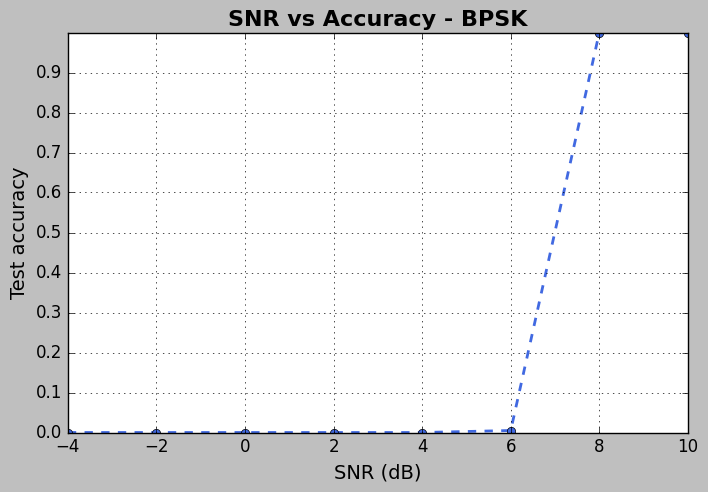

In [3]:
SNR = [2*x for x in range(-2,6)]
accuracy = defaultdict(list)
correctCount = defaultdict(list)
QPSKnumber = defaultdict(list)
QAM16number = defaultdict(list)
QAM64number = defaultdict(list)
for snr in SNR:
    testDataMat,testLabels = file2matrix('matlab_source/digits/testBPSK-' + str(snr) + '.dat')  # load data setfrom file
    numTestVecs = testDataMat.shape[0]
    correctCount[snr] = 0.0
    QPSKnumber[snr] = 0.0
    QAM16number[snr] = 0.0
    QAM64number[snr] = 0.0
    for i in range(numTestVecs):

        X_predict = testDataMat[i, :].reshape(1, -1)
        y_predict = kNN_classifier.predict(X_predict)
        if (y_predict == 2): correctCount[snr] += 1.0
        if (y_predict == 4): QPSKnumber[snr] +=1.0
        if (y_predict == 16): QAM16number[snr] += 1.0
        if (y_predict == 64): QAM64number[snr] += 1.0
    accuracy[snr] = correctCount[snr] / (numTestVecs)
    print("the total correct rate on %d dB SNR is:" % (snr), (accuracy[snr]))
    print("正确判断为BPSK:" , correctCount[snr])
    print("判断为QPSK:" , QPSKnumber[snr])
    print("判断为16QAM:" ,  QAM16number[snr])
    print("判断为64QAM:" ,  QAM64number[snr])
    accuracy = collections.OrderedDict(sorted(accuracy.items()))  # sort by ascending SNR values

#画图
print (accuracy)
plt.style.use('classic')
plt.figure(figsize=(8, 5), dpi=100)
x = SNR
y = list(accuracy.values())
plt.plot(x, y, marker="o", linewidth=2.0, linestyle='dashed', color='royalblue')
plt.axis([0, 10, 0, 1])
plt.xticks(np.arange(min(x), max(x)+1, 2.0))  #横坐标范围及间隔
plt.yticks(np.arange(0, 1, 0.10))

ttl = plt.title('SNR vs Accuracy - BPSK', fontsize=16)
ttl.set_weight('bold')
plt.xlabel('SNR (dB)', fontsize=14)
plt.ylabel('Test accuracy', fontsize=14)
plt.grid()

plt.show()

### QPSKModulationClassTest

the total correct rate on -4 dB SNR is: 0.0
判断为BPSK: 0.0
正确判断为QPSK: 0.0
判断为16QAM: 2.0
判断为64QAM: 998.0
the total correct rate on -2 dB SNR is: 0.0
判断为BPSK: 0.0
正确判断为QPSK: 0.0
判断为16QAM: 2.0
判断为64QAM: 998.0
the total correct rate on 0 dB SNR is: 0.0
判断为BPSK: 0.0
正确判断为QPSK: 0.0
判断为16QAM: 1.0
判断为64QAM: 999.0
the total correct rate on 2 dB SNR is: 0.0
判断为BPSK: 0.0
正确判断为QPSK: 0.0
判断为16QAM: 0.0
判断为64QAM: 1000.0
the total correct rate on 4 dB SNR is: 0.0
判断为BPSK: 0.0
正确判断为QPSK: 0.0
判断为16QAM: 4.0
判断为64QAM: 996.0
the total correct rate on 6 dB SNR is: 0.0
判断为BPSK: 0.0
正确判断为QPSK: 0.0
判断为16QAM: 945.0
判断为64QAM: 55.0
the total correct rate on 8 dB SNR is: 0.0
判断为BPSK: 0.0
正确判断为QPSK: 0.0
判断为16QAM: 1000.0
判断为64QAM: 0.0
the total correct rate on 10 dB SNR is: 0.47
判断为BPSK: 0.0
正确判断为QPSK: 470.0
判断为16QAM: 530.0
判断为64QAM: 0.0
OrderedDict({-4: 0.0, -2: 0.0, 0: 0.0, 2: 0.0, 4: 0.0, 6: 0.0, 8: 0.0, 10: 0.47})


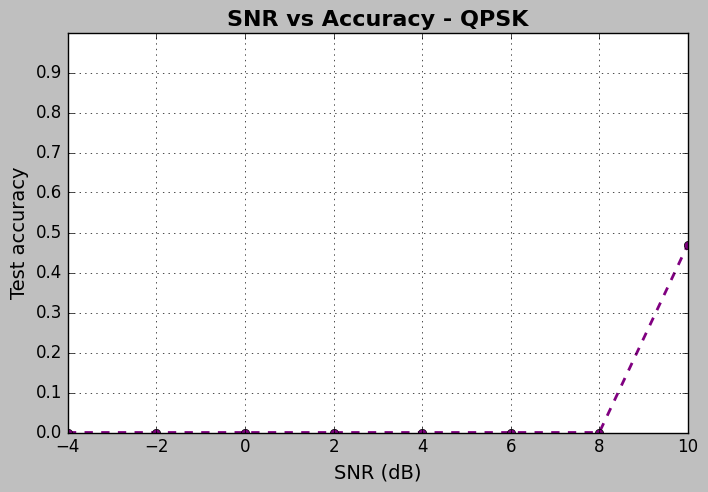

In [4]:
SNR = [2*x for x in range(-2,6)]
accuracy = defaultdict(list)
correctCount = defaultdict(list)
BPSKnumber = defaultdict(list)
QAM16number = defaultdict(list)
QAM64number = defaultdict(list)
for snr in SNR:
    testDataMat, testLabels = file2matrix('matlab_source/digits/testQPSK-' + str(snr) + '.dat')  # load data setfrom file
    numTestVecs = testDataMat.shape[0]
    correctCount[snr] = 0.0
    BPSKnumber[snr] = 0.0
    QAM16number[snr] = 0.0
    QAM64number[snr] = 0.0
    for i in range(numTestVecs):

        X_predict = testDataMat[i, :].reshape(1, -1)
        y_predict = kNN_classifier.predict(X_predict)

        if (y_predict == 2): BPSKnumber[snr] += 1.0
        if (y_predict == 4): correctCount[snr] += 1.0
        if (y_predict == 16): QAM16number[snr] += 1.0
        if (y_predict == 64): QAM64number[snr] += 1.0
    accuracy[snr] = correctCount[snr] / (numTestVecs)
    print("the total correct rate on %d dB SNR is:" % (snr), (accuracy[snr]))
    print("判断为BPSK:", BPSKnumber[snr])
    print("正确判断为QPSK:", correctCount[snr])
    print("判断为16QAM:", QAM16number[snr])
    print("判断为64QAM:", QAM64number[snr])
    accuracy = collections.OrderedDict(sorted(accuracy.items()))  # sort by ascending SNR values

# 画图
print(accuracy)
plt.style.use('classic')
plt.figure(figsize=(8, 5), dpi=100)
x = SNR
y = list(accuracy.values())
plt.plot(x, y, marker="o", linewidth=2.0, linestyle='dashed', color='#800080')
plt.axis([0, 10, 0, 1])
plt.xticks(np.arange(min(x), max(x) + 1, 2.0))
plt.yticks(np.arange(0, 1, 0.10))

ttl = plt.title('SNR vs Accuracy - QPSK', fontsize=16)
ttl.set_weight('bold')
plt.xlabel('SNR (dB)', fontsize=14)
plt.ylabel('Test accuracy', fontsize=14)
plt.grid()

plt.show()

### 16QAM ModulationClassTest

the total correct rate on 0 dB SNR is: 0.0
判断为BPSK: 0.0
判断为QPSK: 0.0
正确判断为16QAM: 0.0
判断为64QAM: 1000.0
the total correct rate on 5 dB SNR is: 0.0
判断为BPSK: 0.0
判断为QPSK: 0.0
正确判断为16QAM: 0.0
判断为64QAM: 1000.0
the total correct rate on 10 dB SNR is: 0.014
判断为BPSK: 0.0
判断为QPSK: 0.0
正确判断为16QAM: 14.0
判断为64QAM: 986.0
the total correct rate on 15 dB SNR is: 0.563
判断为BPSK: 0.0
判断为QPSK: 0.0
正确判断为16QAM: 563.0
判断为64QAM: 437.0
the total correct rate on 20 dB SNR is: 0.891
判断为BPSK: 0.0
判断为QPSK: 0.0
正确判断为16QAM: 891.0
判断为64QAM: 109.0
the total correct rate on 25 dB SNR is: 0.956
判断为BPSK: 0.0
判断为QPSK: 0.0
正确判断为16QAM: 956.0
判断为64QAM: 44.0
the total correct rate on 30 dB SNR is: 0.965
判断为BPSK: 0.0
判断为QPSK: 0.0
正确判断为16QAM: 965.0
判断为64QAM: 35.0
the total correct rate on 35 dB SNR is: 0.968
判断为BPSK: 0.0
判断为QPSK: 0.0
正确判断为16QAM: 968.0
判断为64QAM: 32.0
the total correct rate on 40 dB SNR is: 0.975
判断为BPSK: 0.0
判断为QPSK: 0.0
正确判断为16QAM: 975.0
判断为64QAM: 25.0
OrderedDict({0: 0.0, 5: 0.0, 10: 0.014, 15: 0.563, 20: 0.89

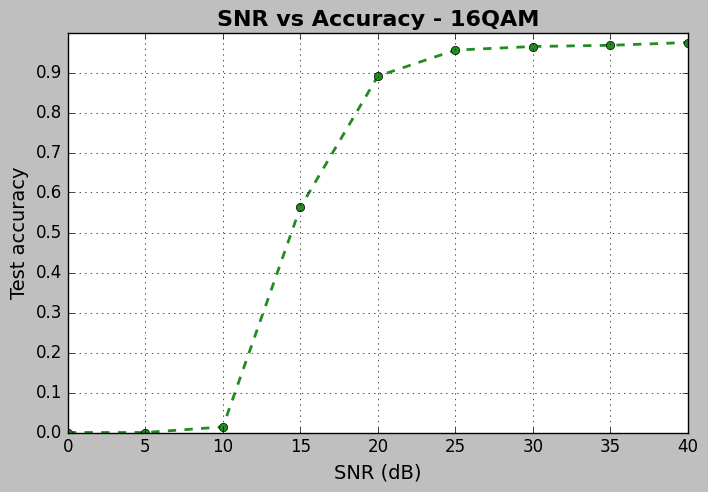

In [5]:
SNR = [5*x for x in range(0, 9)]
accuracy = defaultdict(list)
correctCount = defaultdict(list)
BPSKnumber = defaultdict(list)
QPSKnumber = defaultdict(list)
QAM64number = defaultdict(list)
for snr in SNR:
    testDataMat, testLabels = file2matrix('matlab_source/digits/test16QAM-' + str(snr) + '.dat')  # load data setfrom file
    numTestVecs = testDataMat.shape[0]
    correctCount[snr] = 0.0
    BPSKnumber[snr] = 0.0
    QPSKnumber[snr] = 0.0
    QAM64number[snr] = 0.0
    for i in range(numTestVecs):

        X_predict = testDataMat[i, :].reshape(1, -1)
        y_predict = kNN_classifier.predict(X_predict)

        if (y_predict == 2): BPSKnumber[snr] += 1.0
        if (y_predict == 4): QPSKnumber[snr] += 1.0
        if (y_predict == 16): correctCount[snr] += 1.0
        if (y_predict == 64): QAM64number[snr] += 1.0
    accuracy[snr] = correctCount[snr] / (numTestVecs)
    print("the total correct rate on %d dB SNR is:" % (snr), (accuracy[snr]))
    print("判断为BPSK:", BPSKnumber[snr])
    print("判断为QPSK:", QPSKnumber[snr])
    print("正确判断为16QAM:", correctCount[snr])
    print("判断为64QAM:", QAM64number[snr])
    accuracy = collections.OrderedDict(sorted(accuracy.items()))  # sort by ascending SNR values

# 画图
print(accuracy)
plt.style.use('classic')
plt.figure(figsize=(8, 5), dpi=100)
x = SNR
y = list(accuracy.values())
plt.plot(x, y, marker="o", linewidth=2.0, linestyle='dashed', color='#228B22')
plt.axis([0, 10, 0, 1])
plt.xticks(np.arange(min(x), max(x) + 1, 5.0))
plt.yticks(np.arange(0, 1, 0.10))

ttl = plt.title('SNR vs Accuracy - 16QAM', fontsize=16)
ttl.set_weight('bold')
plt.xlabel('SNR (dB)', fontsize=14)
plt.ylabel('Test accuracy', fontsize=14)
plt.grid()

plt.show()
